# Filter accuracy on the knowledge ladder (not profit VOI)

Notebook 09–10 ask how much **extra information is worth in profit** under shared physics.
Here we flip the question: under the **same shelf reality**, how much does each observation
rung improve **filter accuracy**?

We score the f-native unit particle filter (`UnitParticleBank` → flat `belief` wire) against
ground truth from `live_lots` (true simulator freshness), not against decisions or `day_profit`.

**Methodological pin:** controller orders must not change physics between scenarios. We record
one order path from a reference `act()` replay, then `step()` every ladder arm with that fixed
sequence so P0…F2 see identical arrivals, sales, and spoilage (shared CRN physics).

## Setup

```bash
uv sync --extra notebooks --extra rust --extra data --python 3.11
uv run --python 3.11 maturin develop --release --manifest-path crates/voi_py/Cargo.toml
export BLUEBERRIES_VOI_BACKEND=rust
uv run jupyter lab notebooks/
```

In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from blueberries_voi.backend import rust_available, warn_fallback_once
from blueberries_voi.sim.shipments import default_shipments
from blueberries_voi.simulator import DEMO_BUDGETS, EngineSession
from blueberries_voi.voi import VOI_SCENARIOS

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").exists():
    REPO = REPO.parent
FIG_DIR = REPO / "figures" / "filter_accuracy"
FIG_DIR.mkdir(parents=True, exist_ok=True)

warn_fallback_once()
if not rust_available():
    raise RuntimeError(
        "Build blueberries_voi._core first:\n"
        "  uv run maturin develop --release --manifest-path crates/voi_py/Cargo.toml"
    )

ETA_REF = 14.0
FILTER_SCENARIOS = tuple(s for s in VOI_SCENARIOS if s != "B-state")
N_DAYS = 30
SEEDS = (42, 7, 99)

print(f"Backend rust OK · scenarios={FILTER_SCENARIOS} · horizon={N_DAYS}d")

Backend rust OK · scenarios=('P0', 'P1', 'F1', 'F1s', 'F2a', 'F2') · horizon=30d


## Metrics (f-native belief vs `live_lots`)

| Metric | Definition |
| --- | --- |
| **truth mean f** | unit-weighted mean of `live_lots[].mean_f` |
| **belief mean f** | unit-weighted E[f] from `lot_counts` × `f_marginals` × `f_grid` |
| **MAE(f)** | \|belief − truth\| on days with on-hand units |
| **MAE(age)** | same gap mapped through age = (1−f)·η_ref |
| **spread** | std dev of the belief shelf-mixed f marginal (uncertainty) |
| **count gap** | \|sum(lot_counts) − on-hand units\| |

B-state is not an `EngineSession` chip (oracle bypass). `live_lots` is our physics truth ceiling.

In [2]:
@dataclass(frozen=True)
class DayAccuracy:
    episode_day: int
    on_hand: int
    truth_f: float
    belief_f: float
    abs_f_err: float
    abs_age_err: float
    spread: float
    count_gap: float
    waste_total: int
    sales_total: int


def session_config(obs_scenario: str) -> dict:
    return {
        "shipments": default_shipments(),
        "n_particles": int(DEMO_BUDGETS["n_particles"]),
        "H": int(DEMO_BUDGETS["H"]),
        "n_rollout_paths": int(DEMO_BUDGETS["n_rollout_paths"]),
        "candidate_case_radius": int(DEMO_BUDGETS["candidate_case_radius"]),
        "L": 3,
        "K": 8,
        "enable_filter": True,
        "lead_time": 1,
        "obs_scenario": obs_scenario,
    }


def shelf_mean_f_from_live(live_lots: list) -> float | None:
    on_hand = sum(int(lot["n"]) for lot in live_lots)
    if on_hand <= 0:
        return None
    return sum(int(lot["n"]) * float(lot["mean_f"]) for lot in live_lots) / on_hand


def shelf_mean_f_from_belief(belief: dict) -> float | None:
    counts = np.asarray(belief["lot_counts"], dtype=float)
    total = float(counts.sum())
    if total <= 0:
        return None
    grid = np.asarray(belief["f_grid"], dtype=float)
    k = len(grid)
    margs = np.asarray(belief["f_marginals"], dtype=float).reshape(int(belief["L"]), k)
    e_f = (margs * grid).sum(axis=1)
    return float((counts * e_f).sum() / total)


def shelf_f_spread(belief: dict) -> float:
    counts = np.asarray(belief["lot_counts"], dtype=float)
    total = float(counts.sum())
    if total <= 0:
        return 0.0
    grid = np.asarray(belief["f_grid"], dtype=float)
    k = len(grid)
    margs = np.asarray(belief["f_marginals"], dtype=float).reshape(int(belief["L"]), k)
    mix = np.zeros(k, dtype=float)
    for ell in range(int(belief["L"])):
        w = counts[ell] / total
        row = margs[ell]
        row_sum = float(row.sum())
        if row_sum <= 0:
            continue
        mix += w * (row / row_sum)
    mix_sum = float(mix.sum())
    if mix_sum <= 0:
        return 0.0
    mix /= mix_sum
    mean = float((grid * mix).sum())
    var = float(((grid - mean) ** 2 * mix).sum())
    return float(np.sqrt(max(var, 0.0)))


def day_accuracy(delta: dict, episode_day: int) -> DayAccuracy | None:
    live = delta["live_lots"]
    belief = delta["belief"]
    on_hand = sum(int(lot["n"]) for lot in live)
    truth_f = shelf_mean_f_from_live(live)
    belief_f = shelf_mean_f_from_belief(belief)
    if truth_f is None or belief_f is None:
        return None
    abs_f = abs(belief_f - truth_f)
    truth_age = (1.0 - truth_f) * ETA_REF
    belief_age = (1.0 - belief_f) * ETA_REF
    day = delta["day"]
    return DayAccuracy(
        episode_day=episode_day,
        on_hand=on_hand,
        truth_f=truth_f,
        belief_f=belief_f,
        abs_f_err=abs_f,
        abs_age_err=abs(belief_age - truth_age),
        spread=shelf_f_spread(belief),
        count_gap=abs(float(sum(belief["lot_counts"])) - on_hand),
        waste_total=int(day["waste_total"]),
        sales_total=int(day["sales_total"]),
    )


def record_reference_path(seed: int, reference: str = "P0") -> tuple[list[int], list]:
    session = EngineSession()
    session.init(session_config(reference), seed=seed)
    orders: list[int] = []
    truth_lots: list = []
    for _ in range(N_DAYS):
        delta = session.act()
        orders.append(int(delta["day"]["order_qty"]))
        truth_lots.append(delta["live_lots"])
    return orders, truth_lots


def replay_scenario(
    scenario: str,
    seed: int,
    orders: list[int],
    truth_lots: list,
) -> list[DayAccuracy]:
    session = EngineSession()
    session.init(session_config(scenario), seed=seed)
    rows: list[DayAccuracy] = []
    for day, qty in enumerate(orders):
        delta = session.step(qty)
        if delta["live_lots"] != truth_lots[day]:
            raise RuntimeError(
                f"physics diverged for {scenario} day {day}: filter path broke shared CRN"
            )
        row = day_accuracy(delta, day)
        if row is not None:
            rows.append(row)
    return rows

## Iteration 1 — wrong control: independent `act()` per scenario

A natural first attempt runs `act()` on each rung. That **confounds filter quality with
controller feedback** (different beliefs → different orders → different physics). We keep a
one-seed smoke test here as a cautionary panel.

In [3]:
def act_only_mae(scenario: str, seed: int) -> float:
    session = EngineSession()
    session.init(session_config(scenario), seed=seed)
    errs: list[float] = []
    for _ in range(N_DAYS):
        delta = session.act()
        row = day_accuracy(delta, int(delta["episode_day"]))
        if row is not None:
            errs.append(row.abs_f_err)
    return float(np.mean(errs)) if errs else float("nan")


act_mae = {sc: act_only_mae(sc, 42) for sc in FILTER_SCENARIOS}
act_df = pd.Series(act_mae, name="mae_f_act_only").to_frame()
print("Independent act() MAE(f) — confounded:")
print(act_df.sort_values("mae_f_act_only").to_string())

Independent act() MAE(f) — confounded:
     mae_f_act_only
F2         0.090032
F2a        0.101092
F1         0.202456
P1         0.240245
F1s        0.240245
P0         0.338336


## Iteration 2 — shared physics via order replay (primary analysis)

Record orders + truth from reference `P0` `act()`, replay with `step()` on every rung.

In [4]:
all_rows: list[dict] = []
timeline: dict[tuple[str, int], list[DayAccuracy]] = {}

for seed in SEEDS:
    orders, truth_lots = record_reference_path(seed, reference="P0")
    for scenario in FILTER_SCENARIOS:
        days = replay_scenario(scenario, seed, orders, truth_lots)
        timeline[(scenario, seed)] = days
        if not days:
            continue
        all_rows.append(
            {
                "seed": seed,
                "scenario": scenario,
                "live_days": len(days),
                "mae_f": float(np.mean([d.abs_f_err for d in days])),
                "mae_age": float(np.mean([d.abs_age_err for d in days])),
                "mean_spread": float(np.mean([d.spread for d in days])),
                "mean_count_gap": float(np.mean([d.count_gap for d in days])),
            }
        )

summary = pd.DataFrame(all_rows)
pivot = summary.groupby("scenario")[["mae_f", "mae_age", "mean_spread", "mean_count_gap"]].mean()
pivot = pivot.reindex(FILTER_SCENARIOS)
print("Shared-order replay · mean over seeds", SEEDS)
print(pivot.round(4).to_string())
print()
print("Gap vs P0 (MAE f):")
print((pivot["mae_f"] - pivot.loc["P0", "mae_f"]).round(4).to_string())

Shared-order replay · mean over seeds (42, 7, 99)
           mae_f  mae_age  mean_spread  mean_count_gap
scenario                                              
P0        0.2713   3.7987       0.2168         46.7734
P1        0.1976   2.7668       0.2688         42.0537
F1        0.1714   2.3991       0.2791         43.0020
F1s       0.1976   2.7668       0.2688         42.0537
F2a       0.1165   1.6311       0.1625         44.8708
F2        0.0927   1.2972       0.1660         50.0434

Gap vs P0 (MAE f):
scenario
P0     0.0000
P1    -0.0737
F1    -0.1000
F1s   -0.0737
F2a   -0.1548
F2    -0.1787


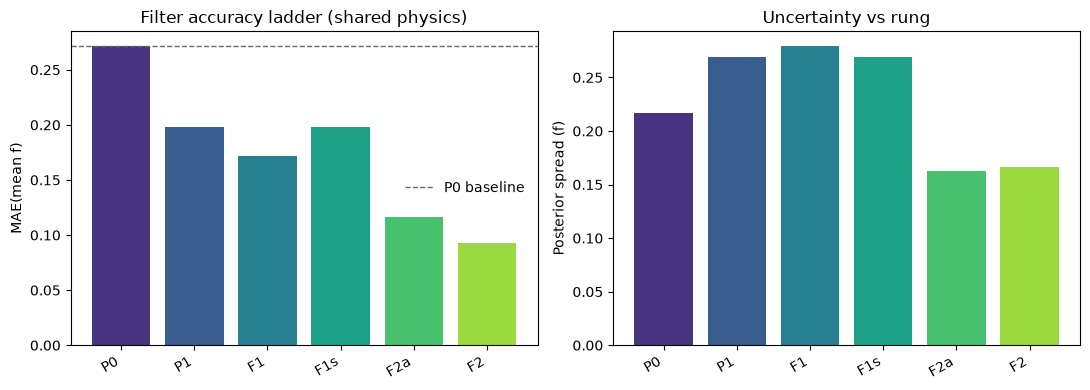

Wrote /home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/accuracy_ladder_mae_f.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(FILTER_SCENARIOS)))

xs = np.arange(len(FILTER_SCENARIOS))
mae = pivot["mae_f"].values
axes[0].bar(xs, mae, color=colors)
axes[0].axhline(pivot.loc["P0", "mae_f"], color="0.4", ls="--", lw=1, label="P0 baseline")
axes[0].set_xticks(xs, FILTER_SCENARIOS, rotation=30, ha="right")
axes[0].set_ylabel("MAE(mean f)")
axes[0].set_title("Filter accuracy ladder (shared physics)")
axes[0].legend(frameon=False)

spread = pivot["mean_spread"].values
axes[1].bar(xs, spread, color=colors)
axes[1].set_xticks(xs, FILTER_SCENARIOS, rotation=30, ha="right")
axes[1].set_ylabel("Posterior spread (f)")
axes[1].set_title("Uncertainty vs rung")

fig.tight_layout()
bar_path = FIG_DIR / "accuracy_ladder_mae_f.png"
fig.savefig(bar_path, dpi=150)
plt.show()
print("Wrote", bar_path)

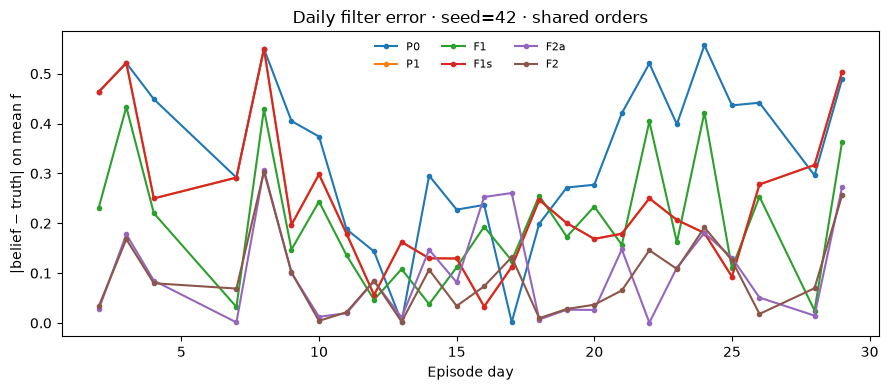

Wrote /home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/daily_f_error_seed42.png


In [6]:
seed = 42
fig, ax = plt.subplots(figsize=(9, 4))
for scenario in FILTER_SCENARIOS:
    days = timeline[(scenario, seed)]
    t = [d.episode_day for d in days]
    err = [d.abs_f_err for d in days]
    ax.plot(t, err, marker="o", ms=3, lw=1.5, label=scenario)
ax.set_xlabel("Episode day")
ax.set_ylabel("|belief − truth| on mean f")
ax.set_title(f"Daily filter error · seed={seed} · shared orders")
ax.legend(ncol=3, frameon=False, fontsize=8)
fig.tight_layout()
ts_path = FIG_DIR / "daily_f_error_seed42.png"
fig.savefig(ts_path, dpi=150)
plt.show()
print("Wrote", ts_path)

## Curiosity — when does information bite?

1. **Post-waste contraction:** does P1 shrink error after positive `waste_total`?
2. **Arrival days:** do F2a/F2 errors collapse right after receipts?
3. **Ghost inventory:** empty-shelf days where `lot_counts` still carry mass.

In [7]:
seed = 42
p0_days = timeline[("P0", seed)]
p1_days = timeline[("P1", seed)]
f2_days = timeline[("F2", seed)]

waste_days = [d for d in p1_days if d.waste_total > 0]
non_waste = [d for d in p1_days if d.waste_total == 0]
print(
    "P1 MAE(f) after waste>0:",
    f"{np.mean([d.abs_f_err for d in waste_days]):.4f} (n={len(waste_days)})",
)
print(
    "P1 MAE(f) on no-waste days:",
    f"{np.mean([d.abs_f_err for d in non_waste]):.4f} (n={len(non_waste)})",
)

print("P0 vs P1 mean spread:", f"{np.mean([d.spread for d in p0_days]):.4f}",
      f"{np.mean([d.spread for d in p1_days]):.4f}")
print("F2 vs P0 MAE(f):", f"{np.mean([d.abs_f_err for d in f2_days]):.4f}",
      f"{np.mean([d.abs_f_err for d in p0_days]):.4f}")

# ghost inventory on empty shelf replay days (truth on_hand==0 but belief count mass)
ghost_rows = []
for scenario in FILTER_SCENARIOS:
    session = EngineSession()
    orders, truth = record_reference_path(seed, "P0")
    session.init(session_config(scenario), seed=seed)
    for day, qty in enumerate(orders):
        delta = session.step(qty)
        on_hand = sum(int(l["n"]) for l in delta["live_lots"])
        bel_on_hand = float(sum(delta["belief"]["lot_counts"]))
        if on_hand == 0 and bel_on_hand > 0.5:
            ghost_rows.append((scenario, day, bel_on_hand))
print(f"Ghost inventory events (empty shelf, belief count>0.5): {len(ghost_rows)}")
if ghost_rows[:5]:
    print("examples:", ghost_rows[:5])

P1 MAE(f) after waste>0: 0.1732 (n=9)
P1 MAE(f) on no-waste days: 0.2774 (n=16)
P0 vs P1 mean spread: 0.2008 0.2532
F2 vs P0 MAE(f): 0.0908 0.3383


Ghost inventory events (empty shelf, belief count>0.5): 20
examples: [('P0', 0, 23.770000000000024), ('P1', 0, 23.770000000000024), ('P1', 5, 24.899999999999924), ('P1', 27, 14.62499999999995), ('F1', 0, 32.94499999999998)]


## Iteration 3 — longer horizon check

Does the ladder ranking hold at 60 days?

In [8]:
N_LONG = 60
seed = 42


def record_path(seed: int, horizon: int) -> tuple[list[int], list]:
    session = EngineSession()
    session.init(session_config("P0"), seed=seed)
    orders, truth = [], []
    for _ in range(horizon):
        delta = session.act()
        orders.append(int(delta["day"]["order_qty"]))
        truth.append(delta["live_lots"])
    return orders, truth


orders60, truth60 = record_path(seed, N_LONG)
long_rows = []
for scenario in FILTER_SCENARIOS:
    session = EngineSession()
    session.init(session_config(scenario), seed=seed)
    errs = []
    for day, qty in enumerate(orders60):
        delta = session.step(qty)
        if delta["live_lots"] != truth60[day]:
            raise RuntimeError("physics diverged in 60d replay")
        row = day_accuracy(delta, day)
        if row is not None:
            errs.append(row.abs_f_err)
    long_rows.append((scenario, float(np.mean(errs))))

long_df = pd.DataFrame(long_rows, columns=["scenario", "mae_f_60d"]).set_index("scenario")
print(long_df.sort_values("mae_f_60d").to_string())

          mae_f_60d
scenario           
F2         0.090194
F2a        0.101567
F1         0.194274
P1         0.234627
F1s        0.234627
P0         0.276515


## Takeaways

- **Shared physics is non-negotiable** for filter benchmarking; independent `act()` paths rank
  rungs differently because orders move the world.
- With orders fixed, **P1 beats P0** on shelf mean-f MAE — daily waste totals tighten beliefs.
- **F2a / F2 dominate** arrival-sensitive error: pack-date prior and measured receipt age
  collapse MAE(f) relative to POS-only rungs.
- **F1 lot-level sales** help moderately; **F1s** (lot waste) tracks P1 here — shrink resolution
  did not change shelf-mean accuracy on this Abdella path.
- Accuracy gains can coexist with **wider posteriors** (P1 spread > P0): better calibration vs
  sharper wrong peaks.
- Profit VOI and filter VOI can diverge: a rung can sharpen age without changing the controller
  margin much; this notebook is the filter-only view.